# Grid types

**What this shows:** the computational grids SWAN supports (regular, curvilinear and
unstructured) and how to write each with rompy-swan, including rotated grids in
projected coordinates.

**Prerequisites:** [Tutorial 2: The computational grid and spectrum](../tutorial/02_grid_and_spectrum.ipynb).

**You will learn:**

- how to set up a rotated regular grid in Cartesian (projected) coordinates
- how to write curvilinear and unstructured `CGRID` commands
- which rompy-swan features need a regular grid
- how to get the coordinates and boundary points of a `SwanGrid`

**Data used:** `etopo15s_perth.nc`, to show the grids in context.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from pyproj import Transformer

from rompy_swan.components.cgrid import CURVILINEAR, REGULAR, UNSTRUCTURED
from rompy_swan.grid import SwanGrid
from rompy_swan.subcomponents.spectrum import SPECTRUM

DATA_DIR = Path("../data")
SPECTRUM_36 = SPECTRUM(mdc=36, flow=0.04, fhigh=1.0)

## 1. A rotated regular grid in projected coordinates

With `COORDINATES CARTESIAN`, positions are in metres. Here the grid is in
MGA zone 50 (EPSG:28350). The coast south of Perth runs north-north-east, so the
grid is rotated by 10° clockwise (`rot=-10`, anticlockwise positive from east) to
align its y-axis with the coast, with the origin offshore. `rot` is SWAN's `alpc`.

In [2]:
utm_grid = SwanGrid(x0=359900.0, y0=6375000.0, rot=-10.0, dx=100.0, dy=100.0, nx=151, ny=301)
print(REGULAR(grid=utm_grid.component, spectrum=SPECTRUM_36).render())

CGRID REGULAR xpc=359900.0 ypc=6375000.0 alpc=-10.0 xlenc=15000.0 ylenc=30000.0 mxc=150 myc=300 CIRCLE mdc=36 flow=0.04 fhigh=1.0


To see where it is, the grid points are converted to longitude and latitude:

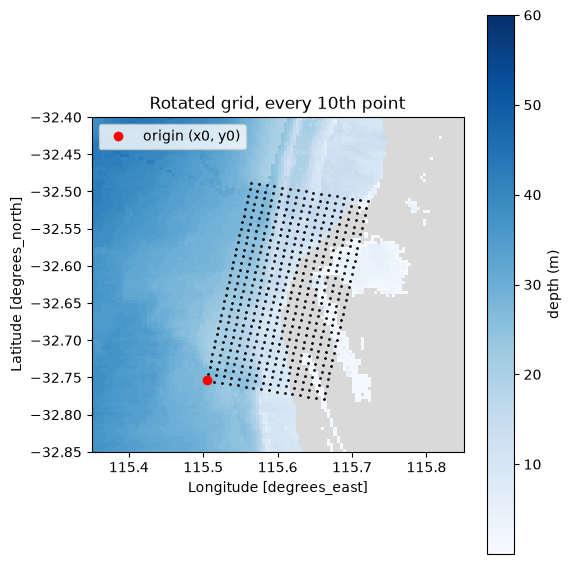

In [3]:
to_lonlat = Transformer.from_crs("EPSG:28350", "EPSG:4326", always_xy=True)
lon, lat = to_lonlat.transform(utm_grid.x, utm_grid.y)

etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc").sel(
    longitude=slice(115.35, 115.85), latitude=slice(-32.85, -32.4)
)
fig, ax = plt.subplots(figsize=(6, 7))
ax.set_facecolor("0.85")
(-etopo.z.where(etopo.z < 0)).plot(ax=ax, cmap="Blues", vmax=60, cbar_kwargs={"label": "depth (m)"})
ax.plot(lon[::10, ::10], lat[::10, ::10], "k.", markersize=2)
ax.plot(lon[0, 0], lat[0, 0], "ro", label="origin (x0, y0)")
ax.legend(loc="upper left")
ax.set_aspect("equal")
ax.set_title("Rotated grid, every 10th point");

Two rules apply to Cartesian grids:

- all inputs (bathymetry, wind, boundary spectra) must be in the same projected
  coordinates, since rompy-swan does not reproject data;
- SWAN recommends small coordinate values, so for large projected coordinates you may
  subtract an offset from the grid and the data.

Regular grids in spherical coordinates cannot be rotated (`rot` must be 0).

## 2. Curvilinear grids

A curvilinear grid follows the coastline or a channel. SWAN reads the coordinates of
its points from a file, given with `READCOORD`. rompy-swan writes the commands; you
provide the coordinate file (`mxc + 1` by `myc + 1` points).

In [4]:
from rompy_swan.subcomponents.readgrid import READCOORD

curvilinear = CURVILINEAR(
    mxc=199,
    myc=99,
    xexc=-999.0,
    yexc=-999.0,
    readcoord=READCOORD(fname="grid_coord.txt"),
    spectrum=SPECTRUM_36,
)
print(curvilinear.render())

CGRID CURVILINEAR mxc=199 myc=99 EXCEPTION xexc=-999.0 yexc=-999.0 CIRCLE mdc=36 flow=0.04 fhigh=1.0
READGRID COORDINATES fac=1.0 fname='grid_coord.txt' idla=1 nhedf=0 nhedvec=0 FREE


`xexc` and `yexc` mark points to ignore, for example on land.

## 3. Unstructured grids

Unstructured (triangular) meshes refine resolution where it is needed. SWAN reads the
mesh from files written by a mesh generator: ADCIRC (`fort.14`), Triangle or Easymesh.

In [5]:
for mesh in [
    UNSTRUCTURED(grid_type="adcirc", spectrum=SPECTRUM_36),
    UNSTRUCTURED(grid_type="triangle", fname="perth_mesh", spectrum=SPECTRUM_36),
]:
    print(mesh.render(), "\n")

CGRID UNSTRUCTURED CIRCLE mdc=36 flow=0.04 fhigh=1.0
READGRID UNSTRUCTURED ADCIRC 

CGRID UNSTRUCTURED CIRCLE mdc=36 flow=0.04 fhigh=1.0
READGRID UNSTRUCTURED TRIANGLE fname='perth_mesh' 



## 4. What needs a regular grid

rompy-swan's data and boundary interfaces crop data and choose boundary points on a
regular grid, so they only work with `REGULAR`:

| Feature | Regular | Curvilinear / unstructured |
|---|---|---|
| `CGRID` command | yes | yes |
| `DataInterface` (data-driven input grids) | yes | no: use hand-written `INPGRIDS` ([Input grids](input_grids.ipynb)) |
| `BoundaryInterface` (spectra from data) | yes | no: use `BOUNDSPEC` or `BOUNDNEST` components |
| Output, physics, numerics | yes | yes |

## 5. Grid geometry

`SwanGrid` gives the coordinates of its points and outline, which are useful for
plotting and checking data coverage.

In [6]:
grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
print("bounding box:", [round(float(v), 2) for v in grid.bbox()])
print("x, y shape:", grid.x.shape)
xbnd, ybnd = grid.boundary_points(spacing=0.1)
print(f"{len(xbnd)} boundary points every 0.1°, as used by the spectral boundaries")

bounding box: [114.5, -32.8, 115.9, -31.5]
x, y shape: (66, 71)
55 boundary points every 0.1°, as used by the spectral boundaries


## Summary

- Regular grids can be spherical (no rotation) or Cartesian (rotated with `rot`); all
  inputs must use the grid's coordinates.
- Curvilinear and unstructured grids read their geometry from files; rompy-swan
  writes the commands.
- The data and boundary interfaces need a regular grid.